In [3]:
import pickle
import os
import sys

sys.path.append(os.path.abspath("../../"))

from preprocesingScripts.bicycles.bicyclesAcquisition_2 import BicyclesAcq

# Lectura de datos
Cómo ya se han leido de forma previa no hace falta hcerlo de nuevo

In [2]:
with open("../../data/bicycles/df_bicycles_correct_station_id.pk1", "rb") as f:
    dfs_per_directory = pickle.load(f)

# Limpieza de datos
- 

In [3]:
years = ["2022", "2023", "2024"]

df_bicycles_preprocesed = BicyclesAcq(years).clean_data_dfs(
    dfs=dfs_per_directory
)

# df_bicycles_preprocesed.df_data.to_pickle("../../data/bicycles/df_bicycles_preprocesed.pk1")


		 --- Grouping, cleaning and analisys data ---


>>>>> Analisys for 2022 <<<<<

		 --- Basic info ---

ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object
          start_lat     start_lng       end_lat       end_lng
count  5.667717e+06  5.667717e+06  5.661859e+06  5.661859e+06
mean   4.190222e+01 -8.764783e+01  4.190242e+01 -8.764790e+01
std    4.626109e-02  2.999925e-02  6.805821e-02  1.082985e-01
min    4.164000e+01 -8.784000e+01  0.000000e+00 -8.814000e+01
25%    4.188103e+01 -8.766154e+01  4.188103e+01 -8.766260e+01
50%    4.190000e+01 -8.764410e+01  4.190000e+01 -8.764414e+01
75%    4.193000e+01 -8.762957e+01  4.193000e+01 -8.762963

In [4]:
df_bicycles_preprocesed.df_data.isna().sum()

ride_id               0
rideable_type         0
started_at            0
ended_at              0
start_station_id      0
start_station_name    0
end_station_id        0
end_station_name      0
member_casual         0
year                  0
month                 0
day                   0
time_hms_ms           0
day_type              0
event                 0
dtype: int64

# Se cambia el id de los station por el correcto

Se ha observado que el id que aparece en los datos no se corresponde con el real en la lista de estaciones, por lo que se cambia

In [5]:
with open("../../data/bicycles/df_bicycles_stations.pk1", "rb") as f:
    stations_bikes = pickle.load(f)

## Al hacer el cambio de IDs se observa que hay muchas estaciones que tienen un id NaN

Se observa además que añadiendo "Public Rack - " se resuelven algunas de ellas

In [6]:
from rapidfuzz import process, fuzz
import pandas as pd

def recover_station_ids(df, stations_bikes, col_name):
    """
    Recupera station_id para un DataFrame df a partir de estaciones.
    col_name: 'start_station' o 'end_station'
    """
    station_id_col = f"{col_name}_id"
    station_name_col = f"{col_name}_name"
    
    # --- Eliminar columna ID existente si ya existe ---
    if station_id_col in df.columns:
        df = df.drop(columns=[station_id_col])
    
    # --- Merge inicial ---
    df = df.merge(
        stations_bikes[['name', 'station_id']],
        left_on=station_name_col,
        right_on='name',
        how='left',
        suffixes=(None, None)  # No crea sufijo, evita columnas duplicadas
    )
    
    # Renombrar columna
    df = df.drop(columns=['name'])
    df = df.rename(columns={'station_id': station_id_col})
    
    # --- Paso 1: Filas sin correspondencia inicial ---
    missing_mask_initial = df[station_id_col].isna()
    initial_missing_count = missing_mask_initial.sum()
    missing_names = df.loc[missing_mask_initial, station_name_col].unique()
    
    print(f"\n📌 {col_name}:")
    print(f"⚠️ Filas sin correspondencia inicial: {initial_missing_count}")
    print(f"🧩 Estaciones únicas sin correspondencia inicial: {len(missing_names)}")
    
    # --- Paso 2: Recuperar con prefijo "Public Rack - " ---
    missing_df = pd.DataFrame({station_name_col: missing_names})
    missing_df['variant'] = "Public Rack - " + missing_df[station_name_col]
    
    found_matches_prefix = missing_df[missing_df['variant'].isin(stations_bikes['name'])]
    
    for original, variant in zip(found_matches_prefix[station_name_col], found_matches_prefix['variant']):
        station_id_value = stations_bikes.loc[stations_bikes['name'] == variant, 'station_id'].iloc[0]
        df.loc[df[station_name_col] == original, station_id_col] = station_id_value
    
    prefix_recovered_count = len(found_matches_prefix)
    print(f"🔍 Coincidencias recuperadas con prefijo 'Public Rack - ': {prefix_recovered_count}")
    
    # --- Paso 3: Recuperar con fuzzy matching ---
    missing_names_fuzzy = df.loc[df[station_id_col].isna(), station_name_col].unique()
    station_names = stations_bikes['name'].tolist()
    
    def fuzzy_match(name, choices, score_cutoff=80):
        result = process.extractOne(
            query=name,
            choices=choices,
            scorer=fuzz.token_sort_ratio,
            score_cutoff=score_cutoff
        )
        if result is not None:
            match, score, _ = result
            return match
        return None
    
    fuzzy_matches = {}
    for name in missing_names_fuzzy:
        match = fuzzy_match(name, station_names)
        if match:
            fuzzy_matches[name] = match
    
    for original, matched in fuzzy_matches.items():
        station_id_value = stations_bikes.loc[stations_bikes['name'] == matched, 'station_id'].iloc[0]
        df.loc[df[station_name_col] == original, station_id_col] = station_id_value
    
    fuzzy_recovered_count = len(fuzzy_matches)
    print(f"🔍 Coincidencias recuperadas con fuzzy matching: {fuzzy_recovered_count}")
    
    # --- Paso 4: Filas que siguen sin correspondencia ---
    missing_mask_final = df[station_id_col].isna()
    remaining_names = df.loc[missing_mask_final, station_name_col].unique()
    final_missing_count = missing_mask_final.sum()
    
    print(f"❌ Filas aún sin correspondencia: {final_missing_count}")
    print(f"Estaciones únicas aún sin encontrar ({len(remaining_names)}):")
    print(sorted(remaining_names))
    
    return df

# Aplicar a start_station
df = recover_station_ids(df_bicycles_preprocesed.df_data, stations_bikes, 'start_station')

# Aplicar a end_station
df = recover_station_ids(df, stations_bikes, 'end_station')



📌 start_station:
⚠️ Filas sin correspondencia inicial: 447352
🧩 Estaciones únicas sin correspondencia inicial: 431
🔍 Coincidencias recuperadas con prefijo 'Public Rack - ': 296
🔍 Coincidencias recuperadas con fuzzy matching: 89
❌ Filas aún sin correspondencia: 247718
Estaciones únicas aún sin encontrar (46):
['410', '63rd & Western Ave - north corner', '63rd & Western Ave - south corner', 'Ashland Ave & 45th St - midblock south', 'Ashland Ave & Division St', 'Austin Ave & Wellington Ave - midblock', 'Base - 2132 W Hubbard', 'Base - 2132 W Hubbard Warehouse', 'Broadway & Wilson - Truman College Vaccination Site', 'Buckingham - Fountain', 'Buckingham Fountain', 'Buckingham Fountain (Columbus/Balbo)', 'Buckingham Fountain (Temp)', 'Cornell Dr & Hayes Dr', 'Damen Ave & Walnut (Lake) St', 'Divvy Valet - Oakwood Beach', 'Eastlake Ter & Rogers Ave', 'Halsted & 63rd - Kennedy-King Vaccination Site', 'Hastings LWS', 'Hastings WH 2', 'La Villita Park (Albany/30th)', 'Lincoln Ave & Belmont Ave (

In [7]:
df = df.drop(columns=['start_station_name', 'end_station_name'])

In [8]:
df.isna().sum()

ride_id                  0
rideable_type            0
started_at               0
ended_at                 0
member_casual            0
year                     0
month                    0
day                      0
time_hms_ms              0
day_type                 0
event                    0
start_station_id    247718
end_station_id      248381
dtype: int64

In [9]:

df = df.dropna(subset=['start_station_id', 'end_station_id'])


In [10]:
df.isna().sum()

ride_id             0
rideable_type       0
started_at          0
ended_at            0
member_casual       0
year                0
month               0
day                 0
time_hms_ms         0
day_type            0
event               0
start_station_id    0
end_station_id      0
dtype: int64

In [11]:
len(df)

9510782

In [12]:
df.head()

,ride_id,rideable_type,started_at,ended_at,member_casual,year,month,day,time_hms_ms,day_type,event,start_station_id,end_station_id
0,C2F7DD78E82EC875,electric_bike,2022-01-13 11:59:47,2022-01-13 12:02:44,casual,2022,1,13,0 days 11:59:47,Normal,False,a3b0fae6-a135-11e9-9cda-0a87ae2ba916,a3ac3b03-a135-11e9-9cda-0a87ae2ba916
1,A6CF8980A652D272,electric_bike,2022-01-10 08:41:56,2022-01-10 08:46:17,casual,2022,1,10,0 days 08:41:56,Normal,False,a3b0fae6-a135-11e9-9cda-0a87ae2ba916,a3ac3b03-a135-11e9-9cda-0a87ae2ba916
2,BD0F91DFF741C66D,classic_bike,2022-01-25 04:53:40,2022-01-25 04:58:01,member,2022,1,25,0 days 04:53:40,Normal,False,a3a4ac3f-a135-11e9-9cda-0a87ae2ba916,a3a76cb6-a135-11e9-9cda-0a87ae2ba916
3,CBB80ED419105406,classic_bike,2022-01-04 00:18:04,2022-01-04 00:33:00,casual,2022,1,4,0 days 00:18:04,Normal,False,a3af368c-a135-11e9-9cda-0a87ae2ba916,a3aa1b5b-a135-11e9-9cda-0a87ae2ba916
4,DDC963BFDDA51EEA,classic_bike,2022-01-20 01:31:10,2022-01-20 01:37:12,member,2022,1,20,0 days 01:31:10,Normal,False,a3a9d529-a135-11e9-9cda-0a87ae2ba916,a3a44476-a135-11e9-9cda-0a87ae2ba916


In [13]:
df.to_pickle("../../data/bicycles/df_bicycles_preprocesed.pk1")

# Se observan los datos

In [4]:
with open("../../data/bicycles/df_bicycles_preprocesed.pk1", "rb") as f:
    df_bicycles = pickle.load(f)

📊 Media de viajes por día: 10783.20


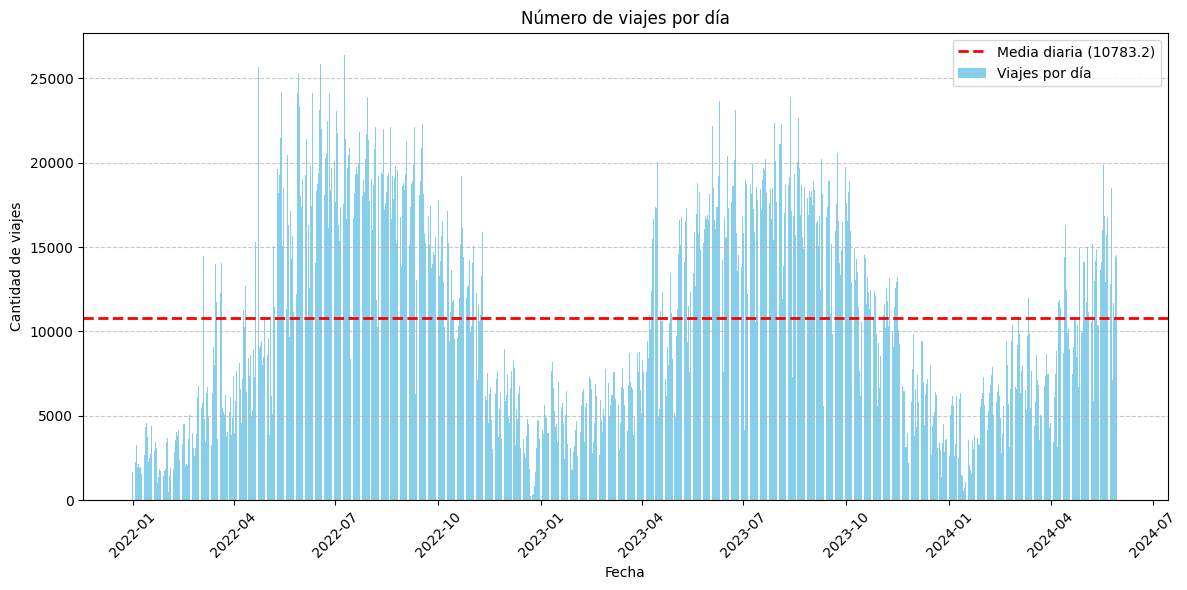

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Asegurarse de que started_at es datetime ---
df_bicycles['started_at'] = pd.to_datetime(df_bicycles['started_at'])

# --- Crear columna de fecha ---
df_bicycles['date'] = df_bicycles['started_at'].dt.date

# --- Agrupar por día y contar viajes ---
trips_per_day = df_bicycles.groupby('date').size()

# --- Calcular media ---
mean_trips_per_day = trips_per_day.mean()
print(f"📊 Media de viajes por día: {mean_trips_per_day:.2f}")

# --- Crear gráfico de barras con línea de media ---
plt.figure(figsize=(12,6))
plt.bar(trips_per_day.index, trips_per_day.values, color='skyblue', label='Viajes por día')
plt.axhline(mean_trips_per_day, color='red', linestyle='--', linewidth=2, label=f'Media diaria ({mean_trips_per_day:.1f})')
plt.title("Número de viajes por día")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajes")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()



# Calculo de la duración media de cada viaje

In [24]:
# Duración en minutos
df_bicycles['duration'] = (df_bicycles['ended_at'] - df_bicycles['started_at']).dt.total_seconds() / 60

In [25]:
# Extraer la fecha de inicio del viaje
df_bicycles['date'] = df_bicycles['started_at'].dt.date

# Calcular media diaria de duración
daily_mean = df_bicycles.groupby('date')['duration'].mean().reset_index()
mean = daily_mean['duration'].mean()

print(f"Media total en minutos: {mean:.2f}")

Media total en minutos: 14.60


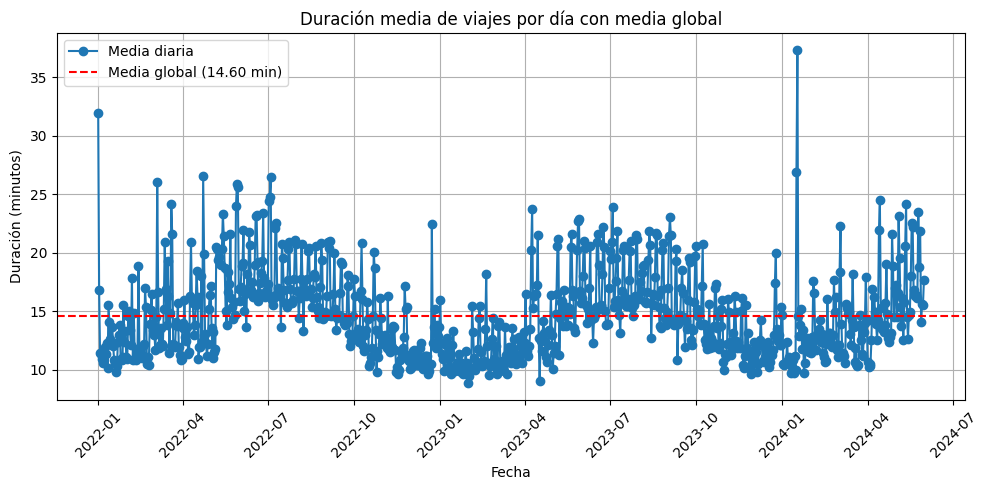

In [26]:
plt.figure(figsize=(10,5))
plt.plot(daily_mean['date'], daily_mean['duration'], marker='o', label='Media diaria')
plt.axhline(mean, color='red', linestyle='--', label=f'Media global ({mean:.2f} min)')
plt.xlabel('Fecha')
plt.ylabel('Duración (minutos)')
plt.title('Duración media de viajes por día con media global')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()